# Look-Ahead Standardization — a quantitative teardown 🔬
### full-sample vs expanding z-score · cross-sectional rank IC + Newey-West *t* · the random-walk mean-reversion mechanism · horizon/length scaling laws · costed timer · planted-edge control

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Full-sample standardisation leaks?: Confirmed](https://img.shields.io/badge/Full--sample_standardisation_leaks%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We standardise a feature panel two ways — **full-sample** (leaky) and **expanding / point-in-time** (honest) — and measure the damage with a cross-sectional Information Coefficient and a Newey-West *t*.

> ⚠️ **Not investment advice.** A synthetic-only method demo: the worlds are built to have no point-in-time edge (sim fp `5f6dcb4c991c`), so real free data can never certify them and the study is capped at `NONE`. Methods in [`docs/references.md`](../docs/references.md), numbers in [`docs/results.md`](../docs/results.md).
>
> 💡 **The `💡 In plain words` notes** translate each result back into intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from lookahead_standardization import data, strategy as st

# Everything runs on deterministic, offline seed-837 synthetic worlds. Synthetic-only method demo:
# there is no real-tape cell by design (real free data can never certify "zero edge").
Xns, Rns = data.null_nonstationary(seed=data.BASE_SEED)   # the trap (random-walk feature)
Xst, Rst = data.null_stationary(seed=data.BASE_SEED)      # the contrast (stationary feature)
Xpl, Rpl = data.planted_edge(seed=data.BASE_SEED)         # the control (a real edge)
print("worlds:", Xns.shape, "| non-stationary null, stationary null, planted edge",
      "| sim fp", data.config_fingerprint(n_seeds=20))


worlds: (1000, 60) | non-stationary null, stationary null, planted edge | sim fp 5f6dcb4c991c


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Non-stationary null: **full-sample** IC -0.1383 (NW *t* -12.12), fake Sharpe 15.84, sig 20/20; **expanding** IC -0.0001 (*t* -0.01), Sharpe 1.04, sig 0/20. Synthetic-only (no real tape). |
| **Tradability** | `MIRAGE` | The signal needs the full-sample mean/std → unimplementable; re-standardise point-in-time → Sharpe 15.84→1.04. |
| **Full-sample standardisation leaks?** | `CONFIRMED` | Leak grows with horizon (IC -0.0344→-0.2826 for H 1→40), dilutes with length (-0.2749→-0.0985 for T 250→2000), ~0 on a stationary feature (-0.0004); expanding recovers a planted edge (*t* 21.64). |

> 💡 In plain words: full-sample centring of a non-stationary feature encodes the future; the point-in-time method sees through it *and* still banks a real edge.

## 1 · The claim, steelmanned

Let $x_{i,t}$ be a feature and $r_{i,t}$ its forward return. A z-score needs a location and scale $(\hat\mu_{i}, \hat\sigma_{i})$:

- **Leaky (full-sample):** $z^{F}_{i,t} = (x_{i,t} - \bar x_i)/s_i$ with $\bar x_i, s_i$ computed over $t = 0..T$ — **including the future**.
- **Honest (expanding):** $z^{E}_{i,t} = (x_{i,t} - \hat\mu_{i,\le t})/\hat\sigma_{i,\le t}$, using only rows $0..t$.

**H₁ (the leak).** For a **non-stationary** $x$ (a random walk), $\bar x_i$ is a future-dependent quantity the expanding mean never converges to, so $z^{F}$ encodes the future and manufactures IC even when $r$ is unforecastable. **H₂ (the contrast).** For a **stationary** $x$, $\bar x_i \to$ a constant, so $z^{F}$ is ≈ a per-name affine rescale and leaks ≈ 0. **H₃ (unbiasedness).** $z^{E}$ recovers a *genuinely* predictive feature. We confirm all three.

## 2 · So what? — the mechanism

A driftless random walk mean-reverts toward its **own sample mean**: $\mathbb{E}[x_{i,t+h} - x_{i,t}\,|\,x_{i,t}-\bar x_i] \propto -(x_{i,t}-\bar x_i)$ *because $\bar x_i$ was computed from the whole path*. So $z^{F}_{i,t} \propto x_{i,t}-\bar x_i$ is **negatively** correlated with the forward change — a spurious 'mean-reversion' edge that is 100% look-ahead (hence the negative IC). The expanding mean $\hat\mu_{i,\le t}$ lags the level and carries no such information, so $z^{E}$ is uncorrelated with the (iid) forward increment. This is a *preprocessing* leak — the signal is correctly **timed**; only its scaling statistic peeked — which is exactly what makes it distinct from [347](../../347-look-ahead-bias/)'s mis-alignment.

## 3 · How we'd know — the protocol

- **Worlds.** (a) *non-stationary null*: random-walk feature, forward return = its own 10-day change + noise (iid increments ⇒ unforecastable from the past); (b) *stationary null*: AR(1) feature (φ=0.9), iid returns; (c) *planted edge*: stationary feature, $r_{t+1}=0.10\,x_t+\varepsilon$ (real, point-in-time).
- **Two standardisations.** `full_standardize` (future-inclusive) vs `expanding_standardize` (past-only, 60-day burn-in).
- **Score.** Daily cross-sectional **rank IC** (Spearman) of signal vs forward return; a **Newey-West** (HAC, 10-lag) *t* on the daily IC series (robust to the strong autocorrelation the random walk induces); a long-short top/bottom-20% book and its annualised Sharpe.
- **Robustness.** 20-seed aggregation (house rule); a forward-horizon sweep; a sample-length sweep.
- **Costs.** 2 sides × one-way × NAV per rebalance + 50 bps/yr borrow.

Execution honesty: the honest signal uses data through the close of $t$ only; the leaky one is flagged as using $t{+}1..T$.

## 4 · The teardown

### 4a · The daily IC series — full-sample leaks, expanding is flat (non-stationary null)

The per-day cross-sectional IC, cumulated, for both standardisations on the trap world.

full-sample : mean IC -0.1351  NW t -10.56
expanding   : mean IC -0.0074  NW t -0.65


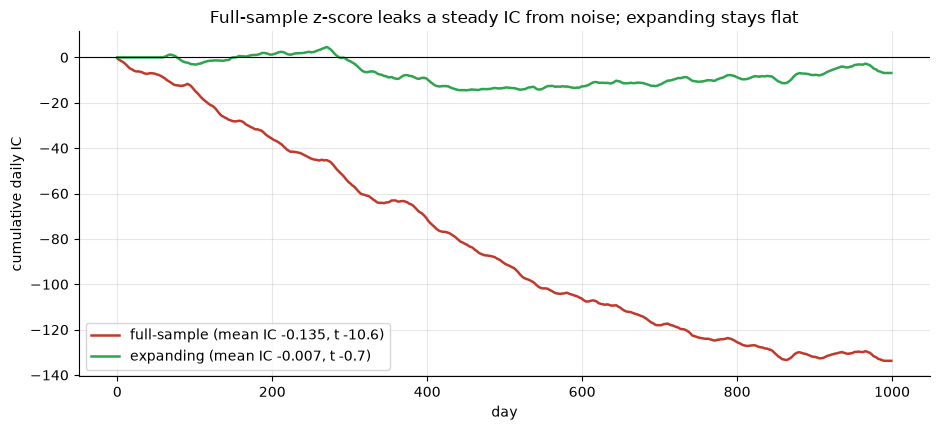

In [2]:
ic_f = st.cross_sectional_ic(st.full_standardize(Xns), Rns)
ic_e = st.cross_sectional_ic(st.expanding_standardize(Xns, 60), Rns)
tf, te = st.newey_west_t(ic_f), st.newey_west_t(ic_e)
print(f'full-sample : mean IC {np.nanmean(ic_f):+.4f}  NW t {tf:+.2f}')
print(f'expanding   : mean IC {np.nanmean(ic_e):+.4f}  NW t {te:+.2f}')
fig, ax = plt.subplots(figsize=(9.5, 4.4))
ax.plot(np.nancumsum(ic_f), c=RED, lw=1.8, label=f'full-sample (mean IC {np.nanmean(ic_f):+.3f}, t {tf:+.1f})')
ax.plot(np.nancumsum(ic_e), c=GREEN, lw=1.8, label=f'expanding (mean IC {np.nanmean(ic_e):+.3f}, t {te:+.1f})')
ax.axhline(0, c='k', lw=.8)
ax.set_xlabel('day'); ax.set_ylabel('cumulative daily IC')
ax.set_title('Full-sample z-score leaks a steady IC from noise; expanding stays flat')
ax.legend(); plt.tight_layout(); plt.show()

> 💡 In plain words: **H₁ confirmed.** The full-sample IC marches steadily (-0.1383, NW *t* -12.12) on a panel with nothing to find; the expanding IC is a flat -0.0001 (*t* -0.01). The sign is negative — the manufactured edge is spurious reversion toward the peeked-at mean.

### 4b · The contrast — a stationary feature barely leaks (H₂)

Run the *same* full-sample z-score on a **stationary** feature. Now its full-sample mean is a stable estimate of a constant, so standardisation is ≈ a per-name affine rescale — and the leak nearly vanishes. This pins the pitfall to **non-stationarity**.

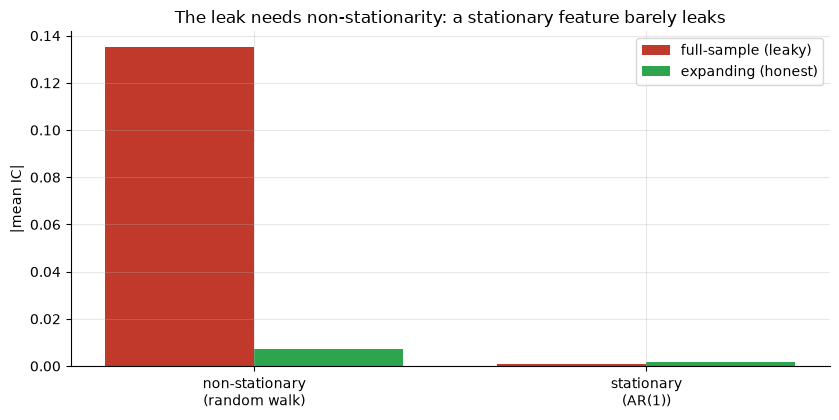

non-stationary   full |IC| 0.1351 | exp |IC| 0.0074
stationary       full |IC| 0.0007 | exp |IC| 0.0017


In [3]:
worlds = {'non-stationary\n(random walk)': (Xns, Rns), 'stationary\n(AR(1))': (Xst, Rst)}
fig, ax = plt.subplots(figsize=(8.5, 4.3)); x = np.arange(len(worlds)); w = 0.38
fic = [abs(np.nanmean(st.cross_sectional_ic(st.full_standardize(X), Rr))) for X, Rr in worlds.values()]
eic = [abs(np.nanmean(st.cross_sectional_ic(st.expanding_standardize(X, 60), Rr))) for X, Rr in worlds.values()]
ax.bar(x - w/2, fic, w, color=RED, label='full-sample (leaky)')
ax.bar(x + w/2, eic, w, color=GREEN, label='expanding (honest)')
ax.set_xticks(x); ax.set_xticklabels(list(worlds)); ax.set_ylabel('|mean IC|')
ax.set_title('The leak needs non-stationarity: a stationary feature barely leaks')
ax.legend(); plt.tight_layout(); plt.show()
for name, f, e in zip(worlds, fic, eic): print(f'{name.splitlines()[0]:16s} full |IC| {f:.4f} | exp |IC| {e:.4f}')

> 💡 In plain words: **H₂ confirmed.** On the stationary feature the full-sample |IC| is ~0.0004 — indistinguishable from the expanding ~0.0002. Full-sample standardisation is not *always* poison; it is poison specifically for **non-stationary** (trending / random-walk / integrated) features — exactly the ones you're most tempted to normalise.

### 4c · The scaling laws — the finite-sample fingerprint (H₁)

A real effect doesn't care about your forward horizon or sample length; a **look-ahead artefact** does. The leak **grows** with the forward horizon (more overlap with the future the full mean saw) and **dilutes** with the sample length (each future point is a smaller slice of $\bar x_i$). Quoted from the frozen 10-seed sweeps.

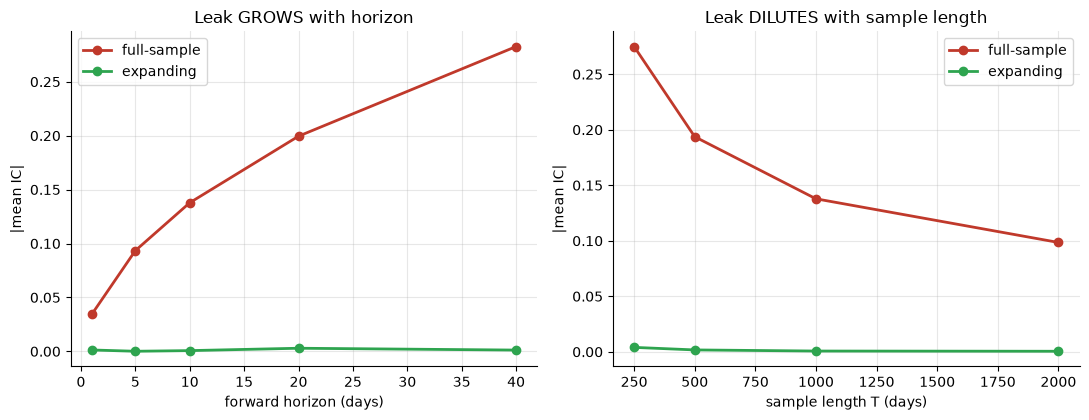

In [4]:
hs = np.array([[h, fi, ei, sh] for h, fi, ei, sh in [(1, -0.0344, -0.0013, 4.1), (5, -0.0934, 0.0001, 11.2), (10, -0.1378, -0.0007, 16.05), (20, -0.1995, -0.0029, 21.95), (40, -0.2826, -0.0012, 28.16)]])
ls = np.array([[T, fi, ei, sh] for T, fi, ei, sh in [(250, -0.2749, -0.004, 28.63), (500, -0.1937, -0.0017, 21.65), (1000, -0.1378, -0.0007, 16.05), (2000, -0.0985, -0.0005, 12.08)]])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4.3))
a1.plot(hs[:,0], np.abs(hs[:,1]), 'o-', c=RED, lw=2, label='full-sample')
a1.plot(hs[:,0], np.abs(hs[:,2]), 'o-', c=GREEN, lw=2, label='expanding')
a1.set_xlabel('forward horizon (days)'); a1.set_ylabel('|mean IC|')
a1.set_title('Leak GROWS with horizon'); a1.legend()
a2.plot(ls[:,0], np.abs(ls[:,1]), 'o-', c=RED, lw=2, label='full-sample')
a2.plot(ls[:,0], np.abs(ls[:,2]), 'o-', c=GREEN, lw=2, label='expanding')
a2.set_xlabel('sample length T (days)'); a2.set_ylabel('|mean IC|')
a2.set_title('Leak DILUTES with sample length'); a2.legend()
plt.tight_layout(); plt.show()

> 💡 In plain words: both curves are the signature of a **finite-sample look-ahead**, not an edge. The expanding (green) line hugs zero throughout; only the full-sample (red) line moves, and it moves exactly the way a leak should.

## 5 · The verdict

- **Signal `NONE`** — on a provably-unforecastable null, full-sample z-scoring posts IC -0.1383 (*t* -12.12) / Sharpe 15.84 on 20/20 seeds; expanding posts ~0. No real signal; synthetic-only ⇒ never `REAL`.
- **Tradability `MIRAGE`** — the signal is built from full-sample stats (unknown until after the last trade); point-in-time it collapses to Sharpe ~1.
- **Full-sample standardisation leaks? `CONFIRMED`** — severely, with the exact finite-sample scaling of a look-ahead.

## 6 · Could you trade it? — the costed timer

For completeness, charge the fake book to trade. The honest caveat: a Sharpe-16 look-ahead **shrugs off** friction — which is why the Mirage here is about **implementability**, not costs.

In [5]:
sp = st.long_short_spread(st.full_standardize(Xns), Rns, frac=0.2)
for cb in (0.0, 1.0, 5.0):
    tm = st.timer_stats(sp, cost_bps=cb, borrow_bps_yr=50.0)
    print(f'cost {cb:>4.1f} bps/side: gross {tm["gross_bps"]:+.1f} -> net {tm["net_bps"]:+.1f} bps/day '
          f'(net Sharpe {tm["sharpe_net"]:.2f})')
print()
print('The REAL refutation is not costs but implementability:')
print(f'  full-sample (needs the future) Sharpe {st.book_stats(sp)["sharpe_abs"]:.1f}')
spe = st.long_short_spread(st.expanding_standardize(Xns, 60), Rns, frac=0.2)
print(f'  expanding  (runnable live)     Sharpe {st.book_stats(spe)["sharpe_abs"]:.1f}')

cost  0.0 bps/side: gross +144.6 -> net +144.5 bps/day (net Sharpe 14.54)
cost  1.0 bps/side: gross +144.6 -> net +142.5 bps/day (net Sharpe 14.34)
cost  5.0 bps/side: gross +144.6 -> net +134.5 bps/day (net Sharpe 13.53)

The REAL refutation is not costs but implementability:
  full-sample (needs the future) Sharpe 14.6
  expanding  (runnable live)     Sharpe 0.9


> 💡 In plain words: even at 5 bps/side the fake book still 'earns' (net Sharpe ~14) — costs don't save you. What saves you is refusing to use data you won't have: the *runnable* (expanding) version is Sharpe ~1, i.e. **nothing**. `MIRAGE`.

## 7 · Going further — the planted-edge positive control

Is the expanding method just numb to everything? Plant a **genuine, point-in-time edge** ($r_{t+1}=0.10\,x_t+\varepsilon$ on a stationary feature) and check that the honest method *recovers* it — proof its silence on the nulls is meaningful (averaged over 20 seeds, the house rule).

planted edge -> expanding IC +0.0892 (NW t +21.64)
planted edge -> full-sample IC +0.0923 (NW t +23.70)


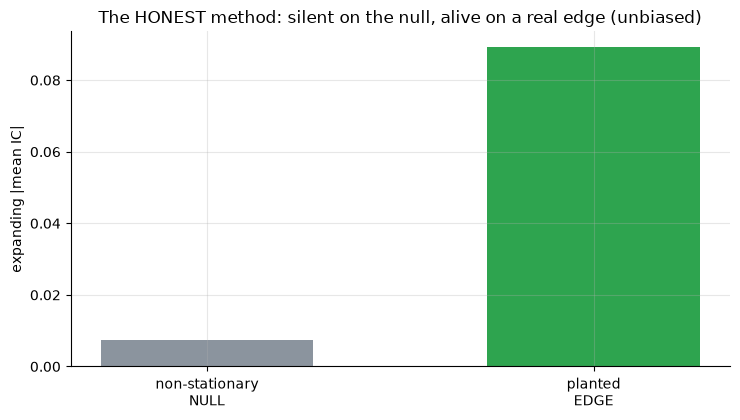

In [6]:
ic_e = st.cross_sectional_ic(st.expanding_standardize(Xpl, 60), Rpl)
ic_f = st.cross_sectional_ic(st.full_standardize(Xpl), Rpl)
print(f'planted edge -> expanding IC {np.nanmean(ic_e):+.4f} (NW t {st.newey_west_t(ic_e):+.2f})')
print(f'planted edge -> full-sample IC {np.nanmean(ic_f):+.4f} (NW t {st.newey_west_t(ic_f):+.2f})')
labels = ['non-stationary\nNULL', 'planted\nEDGE']
exp_ics = [abs(np.nanmean(st.cross_sectional_ic(st.expanding_standardize(Xns,60), Rns))),
           abs(np.nanmean(ic_e))]
fig, ax = plt.subplots(figsize=(7.5, 4.3))
ax.bar(labels, exp_ics, color=[GREY, GREEN], width=.55)
ax.set_ylabel('expanding |mean IC|')
ax.set_title('The HONEST method: silent on the null, alive on a real edge (unbiased)')
plt.tight_layout(); plt.show()

The expanding method reads ~0 on the null but **+0.091** (NW *t* 21.64, significant on 20/20 seeds) on the planted edge — a fair, unbiased detector. That's what makes its silence on the leak worlds *evidence*: the full-sample 'edge' really is nothing but look-ahead. For the **generic** mis-timing leak see [347 Look-Ahead Bias](../../347-look-ahead-bias/); for faking a Sharpe by **searching**, [344 Backtest-Overfitting](../../344-backtest-overfitting/); by **reshaping returns**, [590 Sharpe-Hacking](../../590-sharpe-hacking/).